# 03b — Monte Carlo Individual Simulation

Extends the deterministic baseline (03a) by adding stochastic
variation to three inputs:

1. **TSP investment returns** — year-by-year draws from fitted
   normal distributions for each glide-path L Fund
2. **COLA / inflation** — single draw per iteration, held
   for the full career + retirement. Because the draw
   represents lifetime-average inflation, it is fit on
   rolling 30-year average CPI (mean ≈ 3.4%, std ≈ 1.3%)
   rather than annual inflation, whose volatility would
   overstate the uncertainty of a multi-decade average.
   Clamped >= 0. The same draw drives basic-pay growth
   during service, the pension COLA, and the deflator that
   expresses results in constant 2026 dollars.
3. **Life expectancy** — age at death drawn from
   Normal(SSA 2022 MaleTotalAge, 13 yr) conditioned on sep age

BRS and H3 TSP accounts share the same annual return draws so
the TSP balance difference reflects contribution amounts only.
BRS matching begins after 2 years of service (govt 1% auto in
YOS 1–2, 5% total from YOS 3); the member contributes 5% under
both systems.

**TSP data note:** L Fund returns are extended back to 2002 via
synthetic reconstruction (notebook 01, section 4b). Regression
weights (R² 0.989–0.998) applied to individual-fund returns
(C, S, I, F, G) fill pre-inception years. L 2050 gains 10 years
(n: 14→24), which captures the 2001–2002 tech bust and corrects
a downward bias in its standard deviation estimate.

**Inputs:** `data/processed/pay_profiles.csv`,
`data/processed/tsp_returns.csv`,
`data/processed/cpi_inflation.csv`,
`data/processed/life_expectancy.csv`
**Output:** `data/processed/mc_results.csv`


In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path('../src')))
from monte_carlo import (  # noqa: E402
    DEATH_AGE_STD,
    fit_cola_stats,
    fit_fund_stats,
    run_scenario,
)
from utils import percentile_summary  # noqa: E402

PROCESSED = Path('../data/processed')

## Model constants

In [2]:
PROFILES = ['Officer', 'Enlisted', 'PriorEnlistedOfficer']
# Display order for tables/charts; the run order above is
# kept unchanged to preserve per-scenario seeds
PROFILE_ORDER = [
    'Enlisted', 'PriorEnlistedOfficer', 'Officer'
]
PROFILE_SCENARIOS = {
    'Officer': list(range(4, 41, 2)),
    'Enlisted': list(range(4, 31, 2)),
    'PriorEnlistedOfficer': list(range(4, 41, 2)),
}
ENTRY_AGE = {
    'Officer': 22,
    'Enlisted': 18,
    'PriorEnlistedOfficer': 18,
}
DISCOUNT_RATE = 0.05
N_ITER = 20_000
SEED_BASE = 42
# COLA draw = lifetime-average inflation; fit on rolling
# 30-year average CPI (see fit_cola_stats docstring)
COLA_WINDOW = 30


## Load data

In [3]:
pay_profiles = pd.read_csv(
    PROCESSED / 'pay_profiles.csv'
)
tsp_returns = pd.read_csv(
    PROCESSED / 'tsp_returns.csv'
)
cpi = pd.read_csv(PROCESSED / 'cpi_inflation.csv')
life_exp = pd.read_csv(
    PROCESSED / 'life_expectancy.csv'
)
det_results = pd.read_csv(
    PROCESSED / 'deterministic_results.csv'
)

yr_min = int(cpi['Year'].min())
yr_max = int(cpi['Year'].max())
print(f'pay_profiles: {pay_profiles.shape}')
print(f'tsp_returns:  {tsp_returns.shape}')
print(
    f'cpi:          {cpi.shape}'
    f'  (years {yr_min}-{yr_max})'
)
print(f'life_exp:     {life_exp.shape}')

pay_profiles: (110, 3)
tsp_returns:  (39, 21)
cpi:          (113, 3)  (years 1913-2025)
life_exp:     (120, 5)


## Fit stochastic input distributions

In [4]:
fund_stats = fit_fund_stats(tsp_returns)
cola_stats = fit_cola_stats(cpi, window=COLA_WINDOW)

print('TSP L Fund return distributions:')
hdr = '  {:<12} {:>8} {:>8} {:>4}'
print(hdr.format('Fund', 'Mean', 'Std', 'n'))
print('  ' + '-' * 36)
for fund, s in fund_stats.items():
    n = int(tsp_returns[fund].notna().sum())
    mu, sig = s['mean'], s['std']
    print(f'  {fund:<12} {mu:>8.2%} {sig:>8.2%} {n:>4}')

print()
print(
    f'COLA distribution (rolling {COLA_WINDOW}-yr'
    ' average CPI):'
)
c_mu = cola_stats['mean']
c_sig = cola_stats['std']
print(f'  mean = {c_mu:.2%},  std = {c_sig:.2%}')
print(
    f'  DoD actuarial baseline: 2.75%'
    f'  (fitted mean: {c_mu:.2%})'
)
print()
print(
    f'Life expectancy std: {DEATH_AGE_STD:.0f} yr'
    ' (SSA 2022 middle-age approximation)'
)

TSP L Fund return distributions:
  Fund             Mean      Std    n
  ------------------------------------
  L 2050          9.47%   14.87%   24
  L 2040          8.93%   13.79%   24
  L 2030          8.09%   11.89%   24
  L Income        4.80%    3.74%   24

COLA distribution (rolling 30-yr average CPI):
  mean = 3.39%,  std = 1.27%
  DoD actuarial baseline: 2.75%  (fitted mean: 3.39%)

Life expectancy std: 13 yr (SSA 2022 middle-age approximation)


## Distribution visualization

All three stochastic inputs in one figure, ordered by career
stage. The four L Fund panels share an x-axis range so the
glide path's de-risking is visible as the distributions
narrow from L 2050 to L Income; each shows historical data
with the fitted normal overlay (the sampling distribution
used in simulation). The CPI panel does the same on its own
scale. The death-age panel is purely parametric — Normal
around the SSA 2022 expected total age conditional on
separation age, σ = 13 yr, clipped at the separation age —
shown for the Officer/20 anchor (separation age 42).

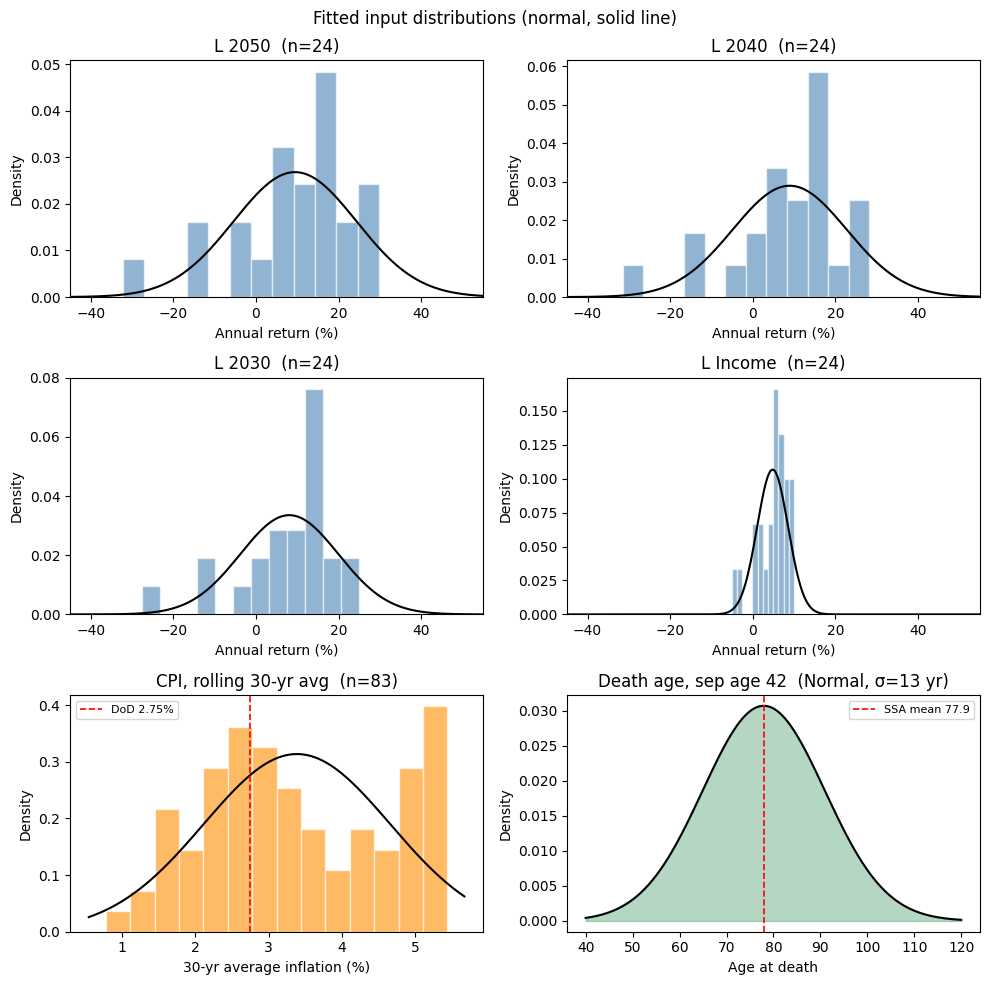

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

# Career-stage order; shared x-range makes the glide path's
# de-risking visible across panels (autoscaling would hide it)
plot_funds = ['L 2050', 'L 2040', 'L 2030', 'L Income']
FUND_XLIM = (-45, 55)
for i, fund in enumerate(plot_funds):
    ax = axes.flat[i]
    vals = tsp_returns[fund].dropna().values
    ax.hist(
        vals, bins=12, density=True,
        alpha=0.6, color='steelblue', edgecolor='white',
    )
    xs = np.linspace(*FUND_XLIM, 300)
    mu = fund_stats[fund]['mean'] * 100
    sigma = fund_stats[fund]['std'] * 100
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma), 'k-', lw=1.5)
    ax.set_xlim(FUND_XLIM)
    n_pts = len(vals)
    ax.set_title(f'{fund}  (n={n_pts})')
    ax.set_xlabel('Annual return (%)')

ax = axes.flat[4]
cpi_roll = (
    cpi.sort_values('Year')['Inflation']
    .dropna()
    .rolling(COLA_WINDOW)
    .mean()
    .dropna()
    .values
)
ax.hist(
    cpi_roll, bins=14, density=True,
    alpha=0.6, color='darkorange', edgecolor='white',
)
xlo, xhi = ax.get_xlim()
xs = np.linspace(xlo, xhi, 200)
ax.plot(
    xs,
    stats.norm.pdf(xs, c_mu * 100, c_sig * 100),
    'k-', lw=1.5,
)
ax.axvline(2.75, color='red', lw=1.2, ls='--',
           label='DoD 2.75%')
n_cpi = len(cpi_roll)
ax.set_title(
    f'CPI, rolling {COLA_WINDOW}-yr avg  (n={n_cpi})'
)
ax.set_xlabel(
    f'{COLA_WINDOW}-yr average inflation (%)'
)
ax.legend(fontsize=8)

# Death age: parametric input (no empirical histogram)
ax = axes.flat[5]
SEP_AGE_DEMO = 42  # Officer/20 anchor
mean_death = float(
    life_exp.loc[
        life_exp['Age'] == SEP_AGE_DEMO,
        'MaleTotalAge',
    ].squeeze()
)
xs = np.linspace(40, 120, 300)
pdf = stats.norm.pdf(xs, mean_death, DEATH_AGE_STD)
ax.fill_between(xs, pdf, color='seagreen', alpha=0.35)
ax.plot(xs, pdf, 'k-', lw=1.5)
ax.axvline(
    mean_death, color='red', lw=1.2, ls='--',
    label=f'SSA mean {mean_death:.1f}',
)
ax.set_title(
    f'Death age, sep age {SEP_AGE_DEMO}'
    f'  (Normal, σ={DEATH_AGE_STD:.0f} yr)'
)
ax.set_xlabel('Age at death')
ax.legend(fontsize=8)

for ax in axes.flat:
    ax.set_ylabel('Density')

fig.suptitle(
    'Fitted input distributions (normal, solid line)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Convergence testing — Officer, 20 YOS

Is 20,000 iterations enough? Test on the most volatile scenario:
run 40,000 iterations and track each reported statistic as N
grows. The chart shows each statistic's deviation from its final
N=40K value; the shaded band is the stability criterion (±1% of
the P10–P90 outcome spread). Estimates must enter the band and
stay there. The table then applies the criterion quantitatively
at the half-to-full step (N=20K vs N=40K).

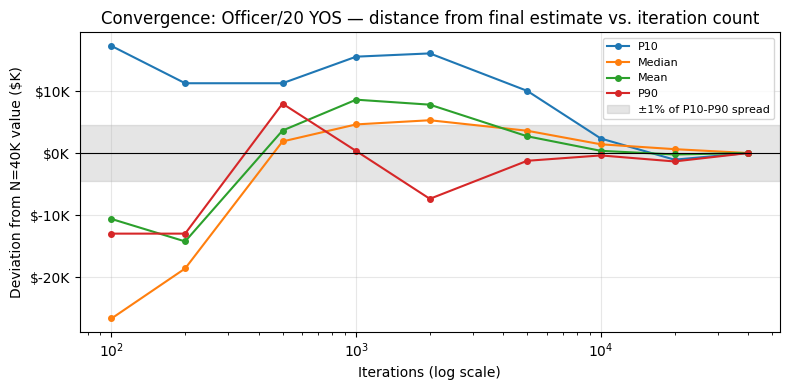

P10-P90 spread at N=40K: $454.1K

     Stat   N=20K ($K)   N=40K ($K)  Shift ($K)   % spread
  ----------------------------------------------------------
      P10       -378.3       -377.3        +1.1      0.24%
   Median       -151.7       -152.3        -0.6      0.14%
     Mean       -152.3       -152.1        +0.2      0.05%
      P90        +75.5        +76.9        +1.4      0.30%

Max shift 20K->40K: 0.30% of spread (on P90) -> PASS (threshold 1%)


In [6]:
conv_raw = run_scenario(
    'Officer', 20,
    pay_profiles, life_exp,
    fund_stats, cola_stats,
    ENTRY_AGE,
    n_iter=40_000,
    discount_rate=DISCOUNT_RATE,
    seed=SEED_BASE,
)
brs_adv_all = conv_raw['brs_adv']

checkpoints = [
    100, 200, 500, 1_000, 2_000,
    5_000, 10_000, 20_000, 40_000,
]
conv_stats = {}
for n in checkpoints:
    sub = brs_adv_all[:n] / 1000
    conv_stats[n] = {
        'p10':  float(np.percentile(sub, 10)),
        'p50':  float(np.percentile(sub, 50)),
        'mean': float(sub.mean()),
        'p90':  float(np.percentile(sub, 90)),
    }

labels = {
    'p10': 'P10', 'p50': 'Median',
    'mean': 'Mean', 'p90': 'P90',
}

# Stability criterion: shift < 1% of the P10-P90 spread
THRESHOLD_PCT = 1.0
final = conv_stats[40_000]
spread_40k = final['p90'] - final['p10']
thr = spread_40k * THRESHOLD_PCT / 100

# Deviation from the final 40K estimate, so all four stats
# share a scale where the early noise is visible
fig, ax = plt.subplots(figsize=(8, 4))
for key, lbl in labels.items():
    devs = [
        conv_stats[n][key] - final[key]
        for n in checkpoints
    ]
    ax.plot(checkpoints, devs, 'o-', ms=4, label=lbl)
ax.axhspan(
    -thr, thr, color='gray', alpha=0.2,
    label=f'±{THRESHOLD_PCT:.0f}% of P10-P90 spread',
)
ax.axhline(0, color='black', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Iterations (log scale)')
ax.set_ylabel('Deviation from N=40K value ($K)')
ax.set_title(
    'Convergence: Officer/20 YOS — distance from final'
    ' estimate vs. iteration count'
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}K')
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Half-to-full check at N=20K vs N=40K
print(f'P10-P90 spread at N=40K: ${spread_40k:,.1f}K')
print()
print(
    f"  {'Stat':>7}  {'N=20K ($K)':>11}"
    f"  {'N=40K ($K)':>11}  {'Shift ($K)':>10}"
    f"  {'% spread':>9}"
)
print('  ' + '-' * 58)
shifts = {}
for key, lbl in labels.items():
    v20 = conv_stats[20_000][key]
    v40 = final[key]
    delta = v40 - v20
    pct = abs(delta) / spread_40k * 100
    shifts[key] = pct
    print(
        f"  {lbl:>7}  {v20:>+11.1f}"
        f"  {v40:>+11.1f}  {delta:>+10.1f}"
        f"  {pct:>8.2f}%"
    )
max_key = max(shifts, key=shifts.get)
verdict = (
    'PASS' if shifts[max_key] < THRESHOLD_PCT else 'FAIL'
)
print()
print(
    f'Max shift 20K->40K: {shifts[max_key]:.2f}% of'
    f' spread (on {labels[max_key]}) -> {verdict}'
    f' (threshold {THRESHOLD_PCT:.0f}%)'
)

## Full Monte Carlo simulation — all 52 scenarios

Each scenario runs 20,000 iterations and is summarized to
percentiles (p10/p25/p50/p75/p90, mean) of the lifetime value
difference (BRS − H3) and the per-system totals. The tables
below show the difference at the 10th, 50th, and 90th
percentiles in constant 2026 \$ thousands — positive means BRS
yields higher lifetime value. P25/P75 and the mean are saved in
`mc_results.csv`; the fan chart below visualizes the bands.

In [7]:
mc_rows = []
scenario_num = 0
t0 = time.perf_counter()

for profile in PROFILES:
    for sep_yos in PROFILE_SCENARIOS[profile]:
        seed = SEED_BASE + scenario_num * 97
        res = run_scenario(
            profile, sep_yos,
            pay_profiles, life_exp,
            fund_stats, cola_stats,
            ENTRY_AGE,
            n_iter=N_ITER,
            discount_rate=DISCOUNT_RATE,
            seed=seed,
        )
        sep_age = ENTRY_AGE[profile] + sep_yos
        summ = {
            'BRSAdv': percentile_summary(res['brs_adv']),
            'H3Total': percentile_summary(
                res['h3_total']
            ),
            'BRSTotal': percentile_summary(
                res['brs_total']
            ),
        }
        row = {
            'Profile': profile,
            'SepYOS': sep_yos,
            'SepAge': sep_age,
            'N_iter': N_ITER,
        }
        for prefix, s in summ.items():
            for k, v in s.items():
                row[f'{prefix}_{k}'] = v
        mc_rows.append(row)
        scenario_num += 1

elapsed = time.perf_counter() - t0
mc_results = pd.DataFrame(mc_rows)
print(
    f'{len(mc_results)} scenarios, '
    f'{N_ITER:,} iterations each, '
    f'{elapsed:.1f}s'
)

52 scenarios, 20,000 iterations each, 2.4s


In [8]:
# One decimal, blanks past a profile's max YOS
FMT = dict(float_format='{:,.1f}'.format, na_rep='')

for pct, lbl in [
    ('p10', '10th percentile'),
    ('p50', 'median'),
    ('p90', '90th percentile'),
]:
    pivot = mc_results.pivot(
        index='Profile',
        columns='SepYOS',
        values=f'BRSAdv_{pct}',
    ).reindex(PROFILE_ORDER) / 1000
    print(
        f'Lifetime value difference, BRS - H3'
        f' ({lbl}), 2026 $ thousands:'
    )
    print(pivot.to_string(**FMT))
    print()

Lifetime value difference, BRS - H3 (10th percentile), 2026 $ thousands:
SepYOS                4    6    8    10   12   14   16   18     20     22     24     26     28     30     32     34     36     38     40
Profile                                                                                                                                 
Enlisted             4.6  9.0 13.9 19.7 25.4 32.7 40.0 48.2 -238.0 -294.4 -337.1 -370.3 -393.2 -407.9                                   
PriorEnlistedOfficer 4.6  9.1 14.2 21.7 30.9 41.8 53.2 65.4 -377.0 -390.3 -437.7 -512.9 -524.3 -590.9 -712.9 -719.9 -748.7 -826.2 -885.9
Officer              8.4 16.8 25.5 36.3 47.0 58.9 71.9 86.5 -374.2 -434.2 -519.4 -557.0 -617.0 -690.4 -784.5 -802.7 -793.0 -784.4 -779.7

Lifetime value difference, BRS - H3 (median), 2026 $ thousands:
SepYOS                 4    6    8    10   12    14    16    18     20     22     24     26     28     30     32     34     36     38     40
Profile                             

## Outcome distributions by career length

Shaded bands show where the simulated futures land: 80% fall
inside the light band (its lower edge is the 10th percentile —
one future in ten ends below it; its upper edge the 90th) and
50% inside the dark band (P25–P75). The dashed line is the
deterministic center-path value from 03a.

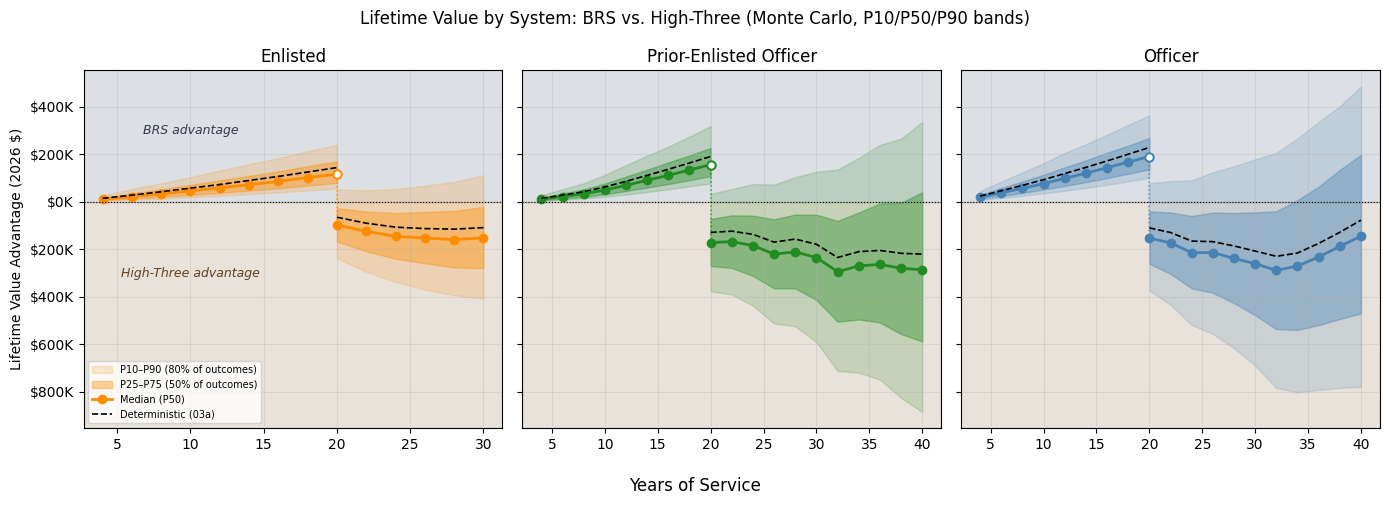

In [9]:
profile_styles = {
    'Enlisted': ('darkorange', 'Enlisted'),
    'PriorEnlistedOfficer': (
        'forestgreen', 'Prior-Enlisted Officer'
    ),
    'Officer': ('steelblue', 'Officer'),
}

# Reproduce mc14's run order to recover the YOS=20 seed per
# profile, so the cusp band below comes from the *same* draws as
# the saved vested band at 20 (seed = SEED_BASE + scenario_num*97).
seed_at_20 = {}
_n = 0
for _prof in PROFILES:
    for _sy in PROFILE_SCENARIOS[_prof]:
        if _sy == 20:
            seed_at_20[_prof] = SEED_BASE + _n * 97
        _n += 1

fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)
for ax, (profile, (color, label)) in zip(
    axes, profile_styles.items()
):
    sub = mc_results[mc_results['Profile'] == profile]
    sub = sub.sort_values('SepYOS')
    det = det_results[det_results['Profile'] == profile]
    det = det.sort_values('SepYOS')
    pre = sub[sub['SepYOS'] < 20]
    post = sub[sub['SepYOS'] >= 20]

    # The pension vests *at* 20, so the difference jumps there.
    # Extend the pre-20 bands to their value on the cusp of
    # vesting: the TSP-only difference distribution (BRS - H3 with
    # no pension), which is what the whole pre-20 band already is.
    # Recomputed from the same simulation (matched seed) since
    # mc_results stores only the with-pension percentiles at 20;
    # no saved results change.
    res20 = run_scenario(
        profile, 20, pay_profiles, life_exp,
        fund_stats, cola_stats, ENTRY_AGE,
        n_iter=N_ITER, discount_rate=DISCOUNT_RATE,
        seed=seed_at_20[profile],
    )
    cusp = percentile_summary(
        res20['brs_tsp_pv'] - res20['h3_tsp_pv']
    )
    c10 = cusp['p10'] / 1000
    c25 = cusp['p25'] / 1000
    c50 = cusp['p50'] / 1000
    c75 = cusp['p75'] / 1000
    c90 = cusp['p90'] / 1000
    xpre = list(pre['SepYOS']) + [20]

    # Pre-cliff bands, extended to the cusp at 20
    ax.fill_between(
        xpre,
        list(pre['BRSAdv_p10'] / 1000) + [c10],
        list(pre['BRSAdv_p90'] / 1000) + [c90],
        alpha=0.18, color=color,
        label='P10–P90 (80% of outcomes)',
    )
    ax.fill_between(
        xpre,
        list(pre['BRSAdv_p25'] / 1000) + [c25],
        list(pre['BRSAdv_p75'] / 1000) + [c75],
        alpha=0.38, color=color,
        label='P25–P75 (50% of outcomes)',
    )
    # Vested bands, 20+
    ax.fill_between(
        post['SepYOS'],
        post['BRSAdv_p10'] / 1000,
        post['BRSAdv_p90'] / 1000,
        alpha=0.18, color=color,
    )
    ax.fill_between(
        post['SepYOS'],
        post['BRSAdv_p25'] / 1000,
        post['BRSAdv_p75'] / 1000,
        alpha=0.38, color=color,
    )
    # Median: pre to the cusp (open marker = limit not attained),
    # dotted drop = the cliff, then the vested 20+ median.
    ax.plot(
        xpre, list(pre['BRSAdv_p50'] / 1000) + [c50],
        '-o', color=color, lw=2, label='Median (P50)',
    )
    vested50 = post.iloc[0]['BRSAdv_p50'] / 1000
    ax.plot(
        [20], [c50], 'o', mfc='white', mec=color,
        mew=1.4, zorder=6,
    )
    ax.plot(
        [20, 20], [c50, vested50], ls=':',
        color=color, lw=1.1, alpha=0.8,
    )
    ax.plot(
        post['SepYOS'], post['BRSAdv_p50'] / 1000,
        '-o', color=color, lw=2,
    )
    # Deterministic (03a), broken at the cliff the same way
    dpre = det[det['SepYOS'] < 20]
    drow20 = det[det['SepYOS'] == 20].iloc[0]
    dcusp = (
        drow20['BRS_TSP_PV'] - drow20['H3TSP_PV']
    ) / 1000
    ax.plot(
        list(dpre['SepYOS']) + [20],
        list(dpre['BRSAdv'] / 1000) + [dcusp],
        'k--', lw=1.2, label='Deterministic (03a)',
    )
    ax.plot(
        det[det['SepYOS'] >= 20]['SepYOS'],
        det[det['SepYOS'] >= 20]['BRSAdv'] / 1000,
        'k--', lw=1.2,
    )

    ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${abs(x):,.0f}K')
    )

# Shade the two halves once the shared y-limits are final:
# above zero BRS advantage, below zero High-Three advantage
# (muted slate / brown, clear of the profile line colors).
ymin, ymax = axes[0].get_ylim()
for ax in axes:
    ax.axhspan(0, ymax, color='#3f5266', alpha=0.18, zorder=0)
    ax.axhspan(ymin, 0, color='#8a6033', alpha=0.18, zorder=0)
    ax.set_ylim(ymin, ymax)

# One legend for all panels (shared axes) on the left panel.
axes[0].legend(fontsize=7, loc='lower left')

# Advantage labels centered near the 10-year mark, by the
# +/-300K lines (left panel only; well clear of the fan lines).
axes[0].text(
    10, 300, 'BRS advantage', ha='center', va='center',
    fontsize=9, style='italic', color='#2f3e4d',
)
axes[0].text(
    10, -300, 'High-Three advantage', ha='center',
    va='center', fontsize=9, style='italic', color='#5e4222',
)

# All-positive axis: tick magnitude is the size of the advantage;
# the shaded region/label says which system it favors.
axes[0].set_ylabel('Lifetime Value Advantage (2026 $)')
fig.supxlabel('Years of Service')
fig.suptitle(
    'Lifetime Value by System: BRS vs. High-Three'
    ' (Monte Carlo, P10/P50/P90 bands)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

## What drives the tails?

The fan chart shows *how wide* the outcome range is; this asks
*why* a simulated future lands at one edge or the other. Group
the 20,000 iterations by outcome — bottom decile, middle 80%,
top decile of the BRS − H3 difference — and compare the average
input draws behind each group.

For a pension-vested career (Officer/20), the futures where
High-Three wins biggest combine high lifetime inflation (4.9%
vs 3.3% typical), a long life (death age 92.5 vs 77.6), and
weak markets (6.9% vs 7.7%) — all three raise the pension's
relative value or lower the TSP's. The P90 tail is the mirror
image, with a short life (66.4) the strongest single separator.
Before the cliff (Officer/10) there is no pension at stake:
death age is not even drawn, COLA barely separates the groups,
and TSP returns are essentially the entire story (4.7% in the
P10 tail vs 11.0% in the P90).

In [10]:
def tail_attribution(profile, sep_yos):
    """Mean input draw within each outcome group."""
    res = run_scenario(
        profile, sep_yos,
        pay_profiles, life_exp,
        fund_stats, cola_stats,
        ENTRY_AGE,
        n_iter=N_ITER,
        discount_rate=DISCOUNT_RATE,
        seed=SEED_BASE,
    )
    adv = res['brs_adv']
    lo, hi = np.percentile(adv, [10, 90])
    groups = {
        'P10 tail': adv <= lo,
        'middle 80%': (adv > lo) & (adv < hi),
        'P90 tail': adv >= hi,
    }
    inputs = [
        ('Lifetime COLA draw', res['cola'], '{:.2%}'),
        ('Avg TSP return draw',
         res['tsp_ret_mean'], '{:.2%}'),
        ('Death age (yrs)', res['death_age'], '{:.1f}'),
    ]
    hdr = '  {:<22}' + '{:>12}' * 3
    print(
        f'{profile}/{sep_yos} — mean input draw by'
        ' outcome group (BRS − H3):'
    )
    print(hdr.format('Input', *groups))
    print('  ' + '-' * 58)
    for name, vals, fmt in inputs:
        if np.isnan(vals).all():
            continue  # not drawn for this scenario
        cells = [
            fmt.format(np.nanmean(vals[m]))
            for m in groups.values()
        ]
        print(hdr.format(name, *cells))
    print()


tail_attribution('Officer', 20)
tail_attribution('Officer', 10)

Officer/20 — mean input draw by outcome group (BRS − H3):
  Input                     P10 tail  middle 80%    P90 tail
  ----------------------------------------------------------
  Lifetime COLA draw           4.90%       3.31%       2.57%
  Avg TSP return draw          6.86%       7.68%      10.14%
  Death age (yrs)               92.5        77.6        66.4

Officer/10 — mean input draw by outcome group (BRS − H3):
  Input                     P10 tail  middle 80%    P90 tail
  ----------------------------------------------------------
  Lifetime COLA draw           3.61%       3.40%       3.15%
  Avg TSP return draw          4.74%       7.84%      10.99%



## Comparison to deterministic baseline

The deterministic value (03a) sits above the MC median in every
scenario, with the gap growing with career length. Two causes:
the empirical COLA mean is higher than the actuarial assumption
(3.39% vs 2.75%), and compounding is asymmetric — an
unusually-high return or inflation draw moves the outcome
further than an equally-unusual low one, so the typical
simulated outcome lands below the deterministic path (Jensen's
inequality). The truncated life-expectancy and COLA
distributions contribute as well. The same effect is why
notebook 05's empirically-centered Officer/20 baseline
(≈ −\$154K) is more negative than 03a's deterministic value
(≈ −\$110K): an intentional empirical-vs-actuarial difference,
not a discrepancy.

In [11]:
compare = mc_results.merge(
    det_results[['Profile', 'SepYOS', 'BRSAdv']],
    on=['Profile', 'SepYOS'],
)
compare['gap_k'] = (
    compare['BRSAdv'] - compare['BRSAdv_p50']
) / 1000

n_pos = (compare['gap_k'] > 0).sum()
print(
    f'Deterministic > MC median in {n_pos} of'
    f' {len(compare)} scenarios.'
)
print()
summ = (
    compare.groupby('Profile')['gap_k']
    .agg(['min', 'median', 'max'])
    .reindex(PROFILE_ORDER)
    .round(1)
)
print('Deterministic − MC median, $K:')
print(summ.to_string())

Deterministic > MC median in 52 of 52 scenarios.

Deterministic − MC median, $K:
                      min  median   max
Profile                                
Enlisted              3.4    22.1  43.9
PriorEnlistedOfficer  3.4    44.0  66.0
Officer               4.7    43.5  67.1


## Save

In [12]:
out = PROCESSED / 'mc_results.csv'
mc_results.to_csv(out, index=False)
sz = out.stat().st_size / 1024
print(f'Saved: {out.name}  ({sz:.1f} KB)')
print(f'Scenarios: {len(mc_results)}')
print(f'Iterations per scenario: {N_ITER:,}')

Saved: mc_results.csv  (18.5 KB)
Scenarios: 52
Iterations per scenario: 20,000
